# **Data Visualization**

In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.

## Objectives

After completing this lab, you will be able to:

-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.

**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:

In [ ]:
#!pip install pandas 
#!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

## Demo: How to work with database

Download the database file.

In [1]:
import pandas as pd

# Dataset URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load dataset
df = pd.read_csv(file_url)

# Display first 5 rows
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:

In [3]:
import sqlite3
import pandas as pd

# Load the CSV dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_url)

# Create SQLite database connection
conn = sqlite3.connect("survey-data.sqlite")

# Insert dataframe into SQLite table
df.to_sql(
    "main",
    conn,
    if_exists="replace",
    index=False
)

print("Database and table created successfully.")

Database and table created successfully.


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:

In [4]:
# Run a simple SQL query to verify the data

query = "SELECT * FROM main LIMIT 5"

result = pd.read_sql_query(query, conn)

# Display the result
print(result)

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

In [5]:
# Check total number of rows in the table

query = "SELECT COUNT(*) AS total_rows FROM main"

row_count = pd.read_sql_query(query, conn)

print(row_count)

   total_rows
0       65437


## Demo: Running an SQL Query

Count the number of rows in the table named 'main'

In [8]:
# SQL query to count rows in the table 'main'

query = "SELECT COUNT(*) AS total_rows FROM main"

result = pd.read_sql_query(query, conn)

print(result)

   total_rows
0       65437


## Demo: Listing All Tables

To view the names of all tables in the database:

In [ ]:
# SQL query to list all tables in the database

query = """
SELECT name 
FROM sqlite_master 
WHERE type='table'
"""

tables = pd.read_sql_query(query, conn)

print(tables)

## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:

In [7]:
# Group respondents by Age and count them

query = """
SELECT Age, COUNT(*) AS Respondent_Count
FROM main
GROUP BY Age
ORDER BY Respondent_Count DESC
"""

age_counts = pd.read_sql_query(query, conn)

print(age_counts)

                  Age  Respondent_Count
0     25-34 years old             23911
1     35-44 years old             14942
2     18-24 years old             14098
3     45-54 years old              6249
4     55-64 years old              2575
5  Under 18 years old              2568
6   65 years or older               772
7   Prefer not to say               322


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:

In [9]:
# Define table name
table_name = 'main'

# SQL query to get schema of the table
QUERY = f"""
SELECT sql 
FROM sqlite_master 
WHERE name = '{table_name}'
"""

# Execute query
schema_df = pd.read_sql_query(QUERY, conn)

# Display schema
print(schema_df.iat[0,0])

CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).

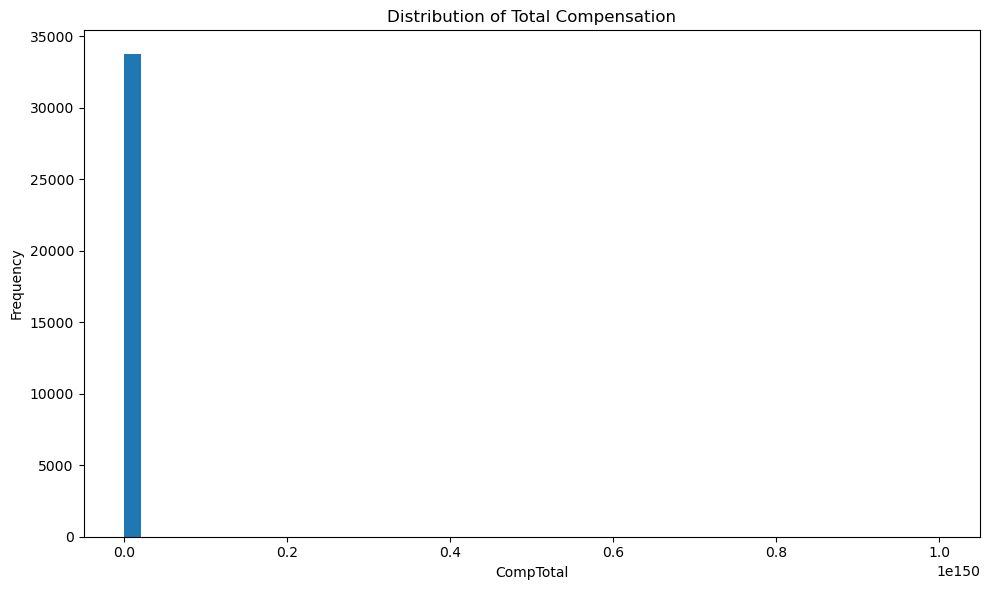

In [12]:
# Plot histogram of CompTotal

plt.figure(figsize=(10,6))

plt.hist(
    df['CompTotal'].dropna(),
    bins=50
)

plt.title('Distribution of Total Compensation')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Box Plots**

Plot a box plot of Age.

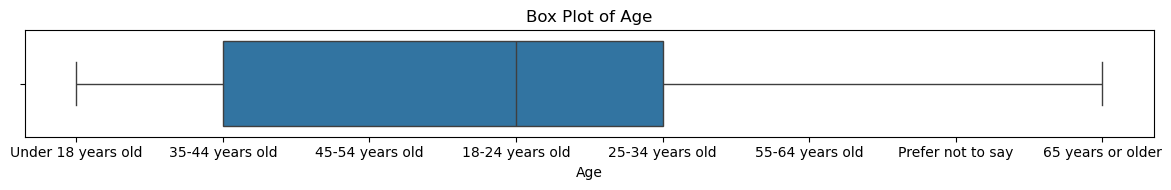

In [13]:
# Plot box plot for Age
import seaborn as sns
plt.figure(figsize=(12,2))

sns.boxplot(
    x=df['Age']
)

plt.title('Box Plot of Age')

plt.tight_layout()
plt.show()

In [14]:
# Better approach: convert Age categories to numeric values

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df['Age_numeric'] = df['Age'].map(age_mapping)

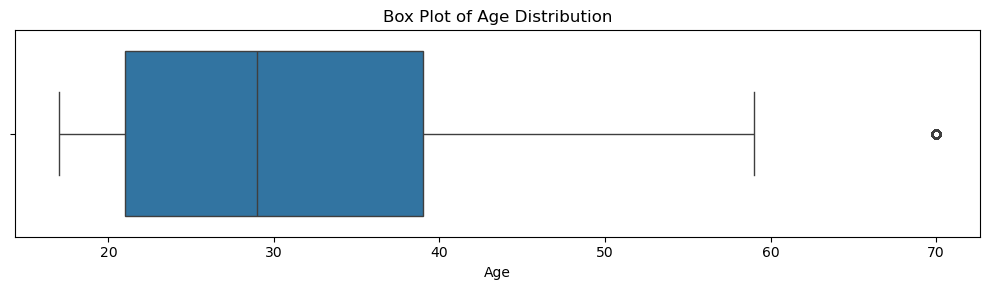

In [15]:
# Plot box plot using numeric age values

plt.figure(figsize=(10,3))

sns.boxplot(
    x=df['Age_numeric']
)

plt.title('Box Plot of Age Distribution')
plt.xlabel('Age')

plt.tight_layout()
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.

In [16]:
# Convert Age column to numeric values

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df['Age_numeric'] = df['Age'].map(age_mapping)

In [17]:
# Convert WorkExp to numeric

df['WorkExp'] = pd.to_numeric(
    df['WorkExp'],
    errors='coerce'
)

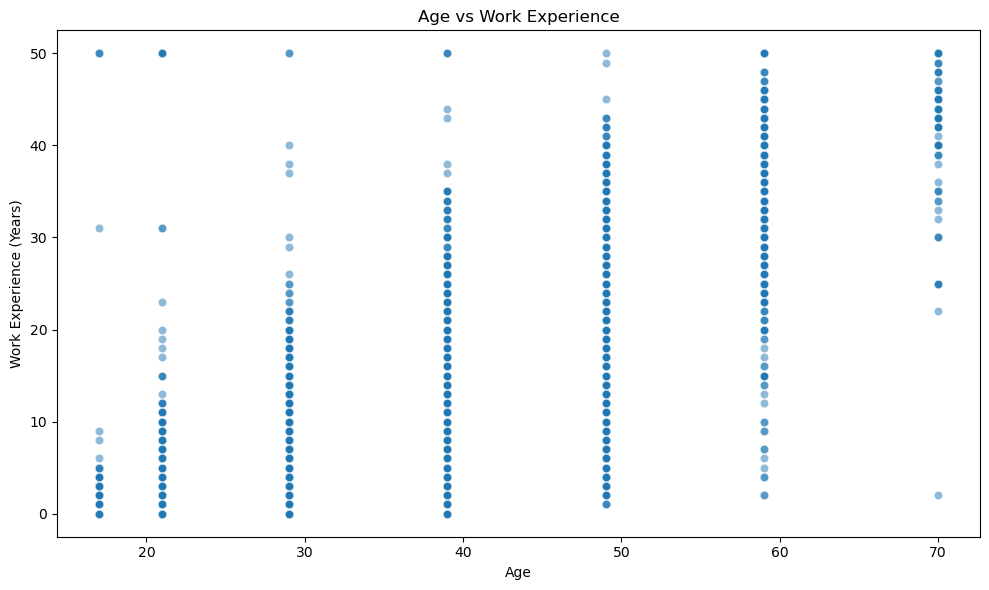

In [18]:
# Create scatter plot of Age vs Work Experience

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Age_numeric',
    y='WorkExp',
    alpha=0.5
)

plt.title('Age vs Work Experience')
plt.xlabel('Age')
plt.ylabel('Work Experience (Years)')

plt.tight_layout()
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.

In [23]:
import pandas as pd

file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_url)

In [24]:
print(df['TimeSearching'].unique()[:10])
print(df['Frustration'].unique()[:10])

[nan '30-60 minutes a day' '60-120 minutes a day' '15-30 minutes a day'
 'Less than 15 minutes a day' 'Over 120 minutes a day']
[nan
 'Amount of technical debt;Number of software tools in use;Tracking my work;Showing my contributions'
 'Amount of technical debt;Complexity of tech stack for deployment'
 'Amount of technical debt;Complexity of tech stack for deployment;Complexity of tech stack for build;Maintaining security of code being produced'
 'Amount of technical debt;Tracking my work;Complexity of tech stack for build;Patching/updating core components;Maintaining security of systems/platforms used in work;Reliability of tools/systems used in work'
 'Number of software tools in use;Tracking my work;Showing my contributions;Complexity of tech stack for build'
 'Amount of technical debt'
 'Amount of technical debt;Number of software tools in use'
 'None of these'
 'Amount of technical debt;Tracking my work;Showing my contributions;Complexity of tech stack for deployment']


In [25]:
# Convert Age to numeric values

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df['Age_numeric'] = df['Age'].map(age_mapping)

In [26]:
# Convert TimeSearching categories into numeric scale

time_mapping = {
    'Less than 15 minutes a day': 1,
    '15-30 minutes a day': 2,
    '30-60 minutes a day': 3,
    '60-120 minutes a day': 4,
    'Over 120 minutes a day': 5
}

df['TimeSearching_num'] = df['TimeSearching'].map(time_mapping)

In [27]:
# Count number of frustrations selected

df['Frustration_Count'] = (
    df['Frustration']
    .fillna('')
    .apply(lambda x: len(x.split(';')) if x != '' else 0)
)

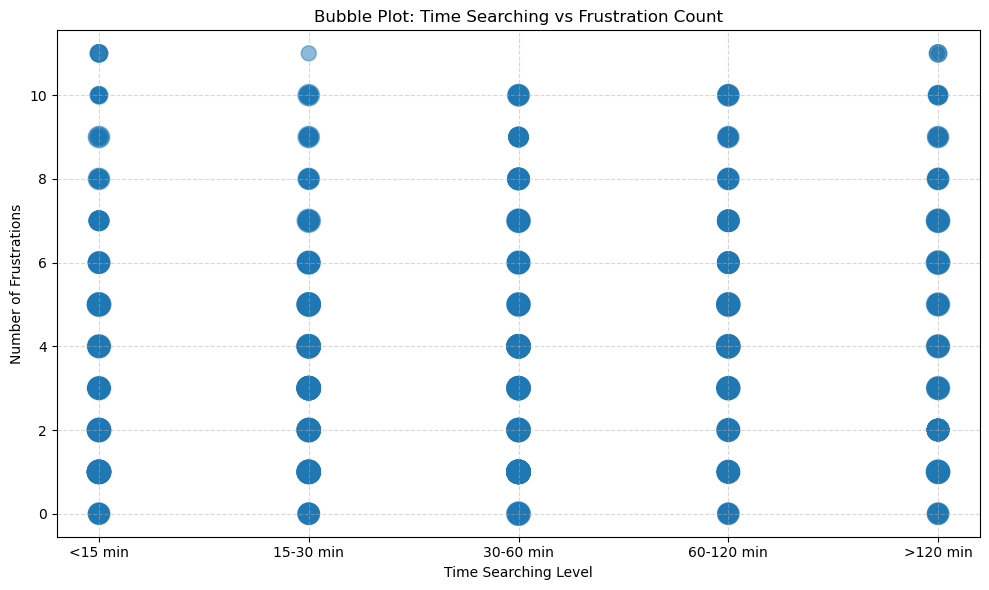

In [28]:
# Create improved bubble plot

plt.figure(figsize=(10,6))

plt.scatter(
    df['TimeSearching_num'],
    df['Frustration_Count'],
    s=df['Age_numeric'] * 4,
    alpha=0.5
)

plt.title('Bubble Plot: Time Searching vs Frustration Count')
plt.xlabel('Time Searching Level')
plt.ylabel('Number of Frustrations')

plt.xticks(
    [1,2,3,4,5],
    [
        '<15 min',
        '15-30 min',
        '30-60 min',
        '60-120 min',
        '>120 min'
    ]
)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.

In [29]:
# Split multiple databases and count frequencies

database_counts = (
    df['DatabaseWantToWorkWith']
    .dropna()
    .str.split(';')
    .explode()
    .value_counts()
    .head(5)
)

print(database_counts)

DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


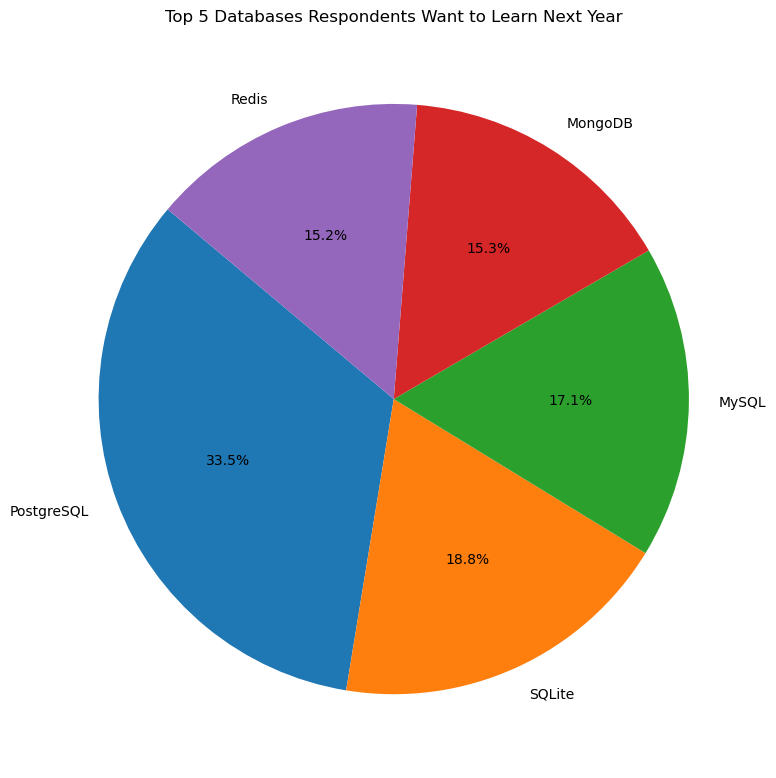

In [30]:
# Create pie chart for top 5 databases

plt.figure(figsize=(8,8))

plt.pie(
    database_counts,
    labels=database_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top 5 Databases Respondents Want to Learn Next Year')

plt.tight_layout()
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.

In [31]:
# Convert Age into approximate numeric values

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df['Age_numeric'] = df['Age'].map(age_mapping)

In [36]:
# Filter age group 25-34 years old

filtered_df = df[
    df['Age'] == '25-34 years old'
].copy()

In [37]:
# Convert categorical time values to numeric scale

time_mapping = {
    'Less than 15 minutes a day': 1,
    '15-30 minutes a day': 2,
    '30-60 minutes a day': 3,
    '60-120 minutes a day': 4,
    'Over 120 minutes a day': 5
}

filtered_df['TimeSearching_num'] = (
    filtered_df['TimeSearching']
    .map(time_mapping)
)

filtered_df['TimeAnswering_num'] = (
    filtered_df['TimeAnswering']
    .map(time_mapping)
)

In [38]:
# Calculate median values

median_searching = filtered_df['TimeSearching_num'].median()
median_answering = filtered_df['TimeAnswering_num'].median()

print("Median TimeSearching:", median_searching)
print("Median TimeAnswering:", median_answering)

Median TimeSearching: 3.0
Median TimeAnswering: 2.0


In [39]:
# Create dataframe for plotting

median_df = pd.DataFrame({
    'Activity': ['TimeSearching', 'TimeAnswering'],
    'Median': [median_searching, median_answering]
})

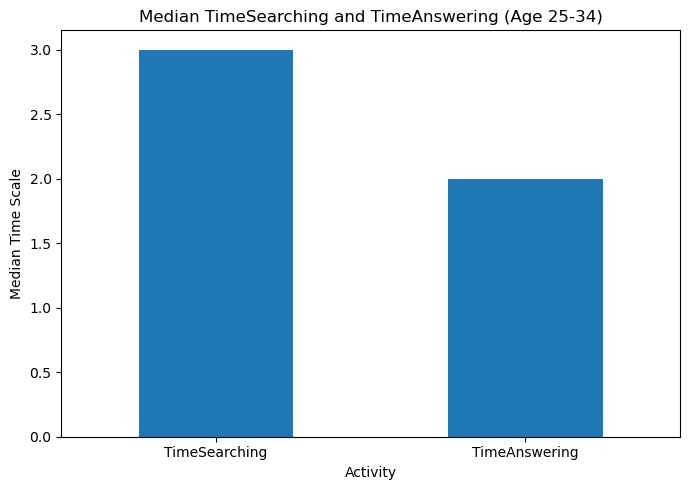

In [40]:
# Plot stacked bar chart

median_df.plot(
    kind='bar',
    x='Activity',
    y='Median',
    stacked=True,
    figsize=(7,5),
    legend=False
)

plt.title('Median TimeSearching and TimeAnswering (Age 25-34)')
plt.xlabel('Activity')
plt.ylabel('Median Time Scale')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.

In [41]:
# Convert Age categories into approximate numeric values

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df['Age_numeric'] = df['Age'].map(age_mapping)

In [42]:
# Filter ages between 45 and 60

filtered_df = df[
    (df['Age_numeric'] >= 45) &
    (df['Age_numeric'] <= 60)
].copy()

In [43]:
# Calculate median compensation for each age

median_comp = (
    filtered_df.groupby('Age_numeric')['CompTotal']
    .median()
    .reset_index()
)

print(median_comp)

   Age_numeric  CompTotal
0         49.0   130000.0
1         59.0   135000.0


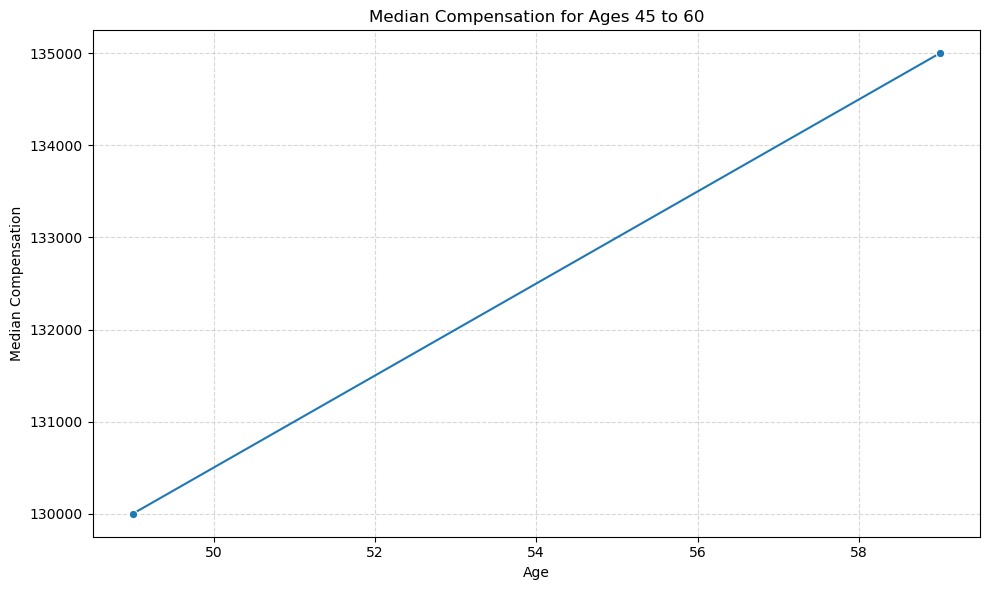

In [44]:
# Create line chart

plt.figure(figsize=(10,6))

sns.lineplot(
    data=median_comp,
    x='Age_numeric',
    y='CompTotal',
    marker='o'
)

plt.title('Median Compensation for Ages 45 to 60')
plt.xlabel('Age')
plt.ylabel('Median Compensation')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.

In [45]:
# Count values in MainBranch column

mainbranch_counts = (
    df['MainBranch']
    .value_counts()
)

print(mainbranch_counts)

MainBranch
I am a developer by profession                                                           50207
I am not primarily a developer, but I write code sometimes as part of my work/studies     6511
I am learning to code                                                                     3875
I code primarily as a hobby                                                               3334
I used to be a developer by profession, but no longer am                                  1510
Name: count, dtype: int64


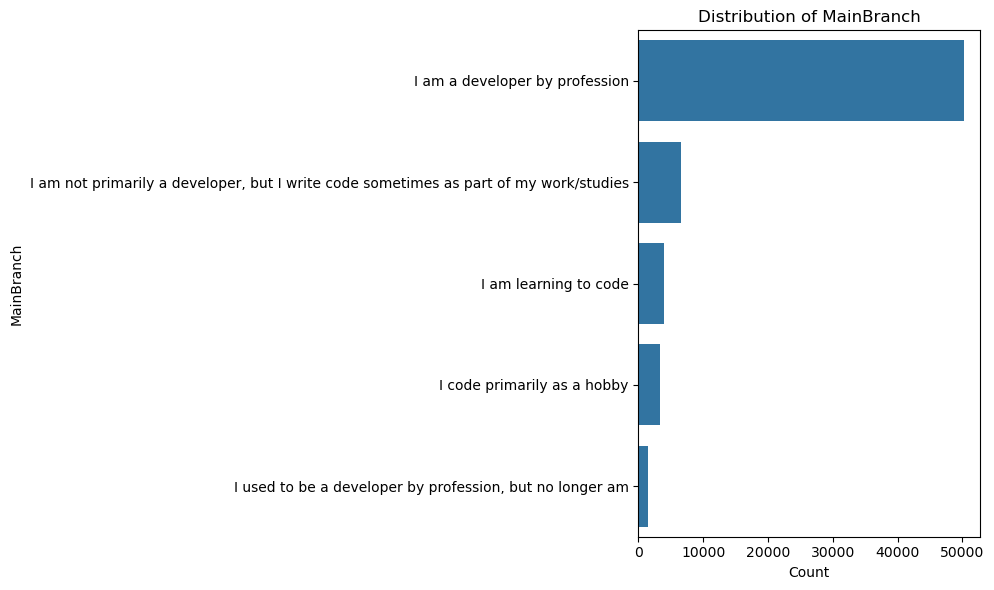

In [46]:
# Create horizontal bar chart

plt.figure(figsize=(10,6))

sns.barplot(
    x=mainbranch_counts.values,
    y=mainbranch_counts.index
)

plt.title('Distribution of MainBranch')
plt.xlabel('Count')
plt.ylabel('MainBranch')

plt.tight_layout()
plt.show()

### Summary

In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.

### Close the Database Connection

Once the lab is complete, ensure to close the database connection:

In [47]:
conn.close()